In [101]:
print(2)

2


In [102]:
import pandas as pd
import numpy as np

DATA_PATH = "/home/jovyan/work/ner_congressional_records/DATA/"

<h1>UNCOMMENT THIS WHILE USING COLLAB</h1>

In [103]:

# from google.colab import drive
# drive.mount('/content/gdrive')
# DATA_PATH = '/content/gdrive/MyDrive/REU/PROJECT/DATA/'

<h1>TRANSACTOR TYPES (CLASSES)</h1>

In [104]:
transactor_types = {
    0: 'Individual',
    1: 'Committee',
    2: 'Company',
    3: 'Party',
}

<h1>PA_TRANSACTORS CSV</h1>

In [105]:
pa_transcators =  pd.read_csv(DATA_PATH+"pa_transactors.csv")
pa_transcators

/tmp/ipykernel_1262/2784178402.py:1: DtypeWarning: Columns (4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  pa_transcators =  pd.read_csv(DATA_PATH+"pa_transactors.csv")


,Unnamed: 0,id,full_name,reported_state,transactor_type,party,phone_number
0,0,8a2df1b3-1ffe-4922-a23e-fefe7cc2ce31,Eli Lilly and Company,PA,NaN,NaN,NaN
1,211,58ebe6de-14fc-4d59-ab12-127ef3615a6d,HDR INC,PA,NaN,NaN,NaN
2,212,9312a5f1-5038-47d1-be0d-ace089d223ca,Ms Lisa A Collie-Pittman,PA,NaN,NaN,NaN
3,213,e4e0aadc-d0e5-4549-bd3e-ffcb77cb4e62,Mrs Kathleen C Solotkin,PA,NaN,NaN,NaN
4,214,da50cf52-f4f1-486b-8d1c-4e1015e98719,Mr Mitchell Silverstein,PA,NaN,NaN,NaN
...,...,...,...,...,...,...,...
1001140,4063818,d4cb91f0-be3b-48ff-85a6-68fe255e03e2,ACH Vantiv,PA,NaN,NaN,NaN
1001141,4063835,bedc5b16-caf0-46db-bdcb-a10651b7cbca,ACT BLUE LLC,PA,NaN,NaN,NaN
1001142,4063836,927f97aa-f338-4a44-879e-cc09576a3530,24HourWristbands,PA,NaN,NaN,NaN
1001143,4063861,44fbaef3-55df-44c0-a9d9-e85b38f8c7f0,ACT BLUE DONATE SERVICE,PA,NaN,NaN,NaN


<h1>AZ_TRANSACTORS CSV</h1>

In [106]:
az_transcators =  pd.read_csv(DATA_PATH+"/az_transactors.csv")

az_transcators

,id,transactor_type,last_name,first_name,middle_name,name_suffix
0,-7,Company,Multiple Vendors,NaN,NaN,NaN
1,-5,Committee,Previous/Next Committee,NaN,NaN,NaN
2,-3,Company,Arizona Secretary of State,NaN,NaN,NaN
3,-2,Company,Citizens Clean Election Commission,NaN,NaN,NaN
4,-1,Individual,Multiple Contributors,NaN,NaN,NaN
...,...,...,...,...,...,...
1048570,1600707,Individual,ORGILL,ANDREW,NaN,NaN
1048571,1600708,Individual,OROZCO,LAURA,NaN,NaN
1048572,1600709,Individual,ORTEGA,CHRIS,NaN,NaN
1048573,1600710,Individual,Ortega,SAYONA,NaN,NaN


<h1>PA_TRANSACTOR_ANNOTATED CSV</h1>

In [107]:
pa_transcator_annotated =  pd.read_csv(DATA_PATH+"pa_transactor_annotated.csv")
pa_transcator_annotated.sort_values(by='full_name')
# pa_transcator_annotated.sort_values(by='party')

,Unnamed: 0,id,full_name,reported_state,transactor_type,party,phone_number
58127,83377,e4a89361-bfe0-4d11-80c1-2f69e0e80c6f,CITIZENS FOR BOYLE,PA,Committee,Democratic Party,NaN
56501,81751,e4a89361-bfe0-4d11-80c1-2f69e0e80c6f,CITIZENS FOR BOYLE,PA,Committee,Democratic Party,NaN
51003,76062,8bdaf5d7-547a-4416-bfae-92d77a3befb4,"MAUCK, SHAWN C",PA,Candidate,Democratic Party,NaN
49377,74388,cd06d2ae-6985-4073-8cfe-130058e3b246,(BOWL PAC),PA,Committee,NaN,7172325322
21980,33257,0030b525-672f-447c-ab87-d6b1ef2b34c1,(OTO PAC),PA,Committee,NaN,7172325322
...,...,...,...,...,...,...,...
6773,9920,bd4ca73b-09ed-4915-a24c-1d7d9145ecbe,maguire pa pac,PA,Committee,NaN,NaN
5890,9011,bd4ca73b-09ed-4915-a24c-1d7d9145ecbe,maguire pa pac,PA,Committee,NaN,NaN
24163,35489,bd4ca73b-09ed-4915-a24c-1d7d9145ecbe,maguire pa pac,PA,Committee,NaN,NaN
5758,8879,bd4ca73b-09ed-4915-a24c-1d7d9145ecbe,maguire pa pac,PA,Committee,NaN,NaN


In [108]:
pa_transcators[pa_transcators['full_name'].isna()]

,Unnamed: 0,id,full_name,reported_state,transactor_type,party,phone_number
14397,54449,83708f03-7052-4a7e-84a8-b69569c1a36b,NaN,PA,NaN,NaN,NaN


In [109]:
pa_transcator_annotated[pa_transcator_annotated['full_name'].isna()]

,Unnamed: 0,id,full_name,reported_state,transactor_type,party,phone_number


<h2>Convert full_name column to lowercase:</h2>
<a href='https://stackoverflow.com/questions/22245171/how-to-lowercase-a-pandas-dataframe-string-column-if-it-has-missing-values'>REFERENCE</a>

In [110]:
pa_transcator_annotated['full_name'] = pa_transcator_annotated['full_name'].str.lower()

In [111]:
pa_transcator_annotated

,Unnamed: 0,id,full_name,reported_state,transactor_type,party,phone_number
0,3008,b60b4b0c-5067-4c44-826b-aac5a22d2609,franklin county reagan coalition,PA,Committee,NaN,7172670032
1,3009,c7461f6f-6118-48eb-a499-fc97d108f66f,nextgen climate action committee,PA,Committee,NaN,NaN
2,3010,14ae9bb5-57dc-422b-b517-8eaaf011cec8,zarwin baum good government pac,PA,Committee,NaN,2155692800
3,3011,7ab4636b-3513-4143-9c17-94115c991a75,mid-atlantic laborers' political league,PA,Committee,NaN,7038604194
4,3012,a445eb91-c855-410d-a046-0a942159d496,toll bros inc pac,PA,Committee,NaN,2159388000
...,...,...,...,...,...,...,...
59625,89718,3913919c-84d3-4a0a-a35a-6d9b896333ea,chris rabb,PA,Candidate,Democratic Party,2672258533
59626,89719,c0db5863-b689-4c81-8d24-ee2dc9a28644,rabb for the people,PA,Committee,Democratic Party,9083770140
59627,89720,af344ea6-acd7-4bb2-a378-d2122df9f94d,bellmon for pa,PA,Candidate,Democratic Party,NaN
59628,89721,cadc2ba5-977a-467b-a77c-1485bcf1234f,friends of fredda maddox,PA,Committee,Democratic Party,4843435787


In [112]:
pa_transcators['full_name'] = pa_transcators['full_name'].str.lower()
pa_transcators

,Unnamed: 0,id,full_name,reported_state,transactor_type,party,phone_number
0,0,8a2df1b3-1ffe-4922-a23e-fefe7cc2ce31,eli lilly and company,PA,NaN,NaN,NaN
1,211,58ebe6de-14fc-4d59-ab12-127ef3615a6d,hdr inc,PA,NaN,NaN,NaN
2,212,9312a5f1-5038-47d1-be0d-ace089d223ca,ms lisa a collie-pittman,PA,NaN,NaN,NaN
3,213,e4e0aadc-d0e5-4549-bd3e-ffcb77cb4e62,mrs kathleen c solotkin,PA,NaN,NaN,NaN
4,214,da50cf52-f4f1-486b-8d1c-4e1015e98719,mr mitchell silverstein,PA,NaN,NaN,NaN
...,...,...,...,...,...,...,...
1001140,4063818,d4cb91f0-be3b-48ff-85a6-68fe255e03e2,ach vantiv,PA,NaN,NaN,NaN
1001141,4063835,bedc5b16-caf0-46db-bdcb-a10651b7cbca,act blue llc,PA,NaN,NaN,NaN
1001142,4063836,927f97aa-f338-4a44-879e-cc09576a3530,24hourwristbands,PA,NaN,NaN,NaN
1001143,4063861,44fbaef3-55df-44c0-a9d9-e85b38f8c7f0,act blue donate service,PA,NaN,NaN,NaN


<h1>JOIN NAMES COLUMNS ON NEW COLUMN 'full_name'.
<h1>

In [113]:
az_transcators['full_name'] = az_transcators['name_suffix'].astype(str) + ' ' + az_transcators['first_name'].astype(str) + ' ' + az_transcators['middle_name'].astype(str) + ' ' + az_transcators['last_name'].astype(str)

In [114]:
az_transcators['full_name'] = az_transcators['full_name'].str.replace('nan', '', regex=False).str.strip()

In [115]:
az_transcators['full_name'] = az_transcators['full_name'].str.lower()
az_transcators

,id,transactor_type,last_name,first_name,middle_name,name_suffix,full_name
0,-7,Company,Multiple Vendors,NaN,NaN,NaN,multiple vendors
1,-5,Committee,Previous/Next Committee,NaN,NaN,NaN,previous/next committee
2,-3,Company,Arizona Secretary of State,NaN,NaN,NaN,arizona secretary of state
3,-2,Company,Citizens Clean Election Commission,NaN,NaN,NaN,citizens clean election commission
4,-1,Individual,Multiple Contributors,NaN,NaN,NaN,multiple contributors
...,...,...,...,...,...,...,...
1048570,1600707,Individual,ORGILL,ANDREW,NaN,NaN,andrew orgill
1048571,1600708,Individual,OROZCO,LAURA,NaN,NaN,laura orozco
1048572,1600709,Individual,ORTEGA,CHRIS,NaN,NaN,chris ortega
1048573,1600710,Individual,Ortega,SAYONA,NaN,NaN,sayona ortega


<h1>PA_TRANSACTORS DUPLICATE VALUES</h1>
<a href='https://stackoverflow.com/questions/12497402/remove-duplicates-by-columns-a-keeping-the-row-with-the-highest-value-in-column'>REFERENCE</a>

In [116]:
pa_transcators.nunique()


Unnamed: 0         1001145
id                  997050
full_name           899516
reported_state           1
transactor_type          3
party                    4
phone_number          4272
dtype: int64

In [117]:
pa_transcators.groupby('full_name').size().sort_values()

full_name
\tcharlton, alexander t friends of    1
michael touhey                        1
michael toussaint                     1
michael tout                          1
michael towery                        1
                                     ..
committee to elect pam snyder         8
committee to re-elect frank burns     8
pnc bank                              8
local 66 pac club                     8
vantiv ecommerce                      9
Length: 899516, dtype: int64

###ONE NAN FULL_NAME ON PA_TRANSACTORS. DROP IT?

In [118]:
pa_transcators[pa_transcators['full_name'].isna()]

,Unnamed: 0,id,full_name,reported_state,transactor_type,party,phone_number
14397,54449,83708f03-7052-4a7e-84a8-b69569c1a36b,NaN,PA,NaN,NaN,NaN


In [119]:
pa_transcators.drop_duplicates(subset='full_name', inplace=True)
pa_transcators.groupby(by='full_name').size().sort_values()


full_name
\tcharlton, alexander t friends of    1
mr michael masnyk jr.                 1
mr michael mitchell                   1
mr michael murphy sr                  1
mr michael nally                      1
                                     ..
glen c sweet                          1
glen c. mutscher                      1
glen c. swope                         1
glen brown                            1
,.abigail loughrey                   1
Length: 899516, dtype: int64

In [120]:
pa_transcators

,Unnamed: 0,id,full_name,reported_state,transactor_type,party,phone_number
0,0,8a2df1b3-1ffe-4922-a23e-fefe7cc2ce31,eli lilly and company,PA,NaN,NaN,NaN
1,211,58ebe6de-14fc-4d59-ab12-127ef3615a6d,hdr inc,PA,NaN,NaN,NaN
2,212,9312a5f1-5038-47d1-be0d-ace089d223ca,ms lisa a collie-pittman,PA,NaN,NaN,NaN
3,213,e4e0aadc-d0e5-4549-bd3e-ffcb77cb4e62,mrs kathleen c solotkin,PA,NaN,NaN,NaN
4,214,da50cf52-f4f1-486b-8d1c-4e1015e98719,mr mitchell silverstein,PA,NaN,NaN,NaN
...,...,...,...,...,...,...,...
1001138,4063805,56e5ed94-6185-45d0-ba9d-e99c65e7138a,5th ward exec committee,PA,NaN,NaN,NaN
1001139,4063809,0e005ea9-1a57-4586-aa54-58ed48c0b5c1,a storage depot,PA,NaN,NaN,NaN
1001142,4063836,927f97aa-f338-4a44-879e-cc09576a3530,24hourwristbands,PA,NaN,NaN,NaN
1001143,4063861,44fbaef3-55df-44c0-a9d9-e85b38f8c7f0,act blue donate service,PA,NaN,NaN,NaN


<h1>AZ_TRANSACTORS DUPLICATE VALUES</h1>

In [121]:
az_transcators.nunique()

id                 1048575
transactor_type          4
last_name           238029
first_name           51275
middle_name           8172
name_suffix            304
full_name           631011
dtype: int64

In [122]:
az_transcators.groupby(by='full_name').size().sort_values()

full_name
jr lyle  stephens       1
maloy s sasser          1
maloy cleda sasser      1
maloy c sasser          1
malouf properties       1
                     ... 
usps                  295
home depot            296
staples               315
bank of america       317
circle k              491
Length: 631011, dtype: int64

In [123]:
az_transcators[az_transcators['full_name'].isna()]

,id,transactor_type,last_name,first_name,middle_name,name_suffix,full_name


In [124]:
az_transcators.drop_duplicates(subset='full_name', inplace=True)
az_transcators.groupby(by='full_name').size().sort_values()



full_name
                            1
melanie  reed               1
melanie  rettler            1
melanie  reynolds           1
melanie  rhinehart          1
                           ..
george p seaman             1
george p tarango            1
george p torgeson           1
george p mills              1
\tindependentvoting.org    1
Length: 631011, dtype: int64

In [125]:
az_transcators


,id,transactor_type,last_name,first_name,middle_name,name_suffix,full_name
0,-7,Company,Multiple Vendors,NaN,NaN,NaN,multiple vendors
1,-5,Committee,Previous/Next Committee,NaN,NaN,NaN,previous/next committee
2,-3,Company,Arizona Secretary of State,NaN,NaN,NaN,arizona secretary of state
3,-2,Company,Citizens Clean Election Commission,NaN,NaN,NaN,citizens clean election commission
4,-1,Individual,Multiple Contributors,NaN,NaN,NaN,multiple contributors
...,...,...,...,...,...,...,...
1048568,1600705,Individual,OLOFSON,CINDY,NaN,NaN,cindy olofson
1048569,1600706,Individual,Olsen,RYAN,NaN,NaN,ryan olsen
1048570,1600707,Individual,ORGILL,ANDREW,NaN,NaN,andrew orgill
1048572,1600709,Individual,ORTEGA,CHRIS,NaN,NaN,chris ortega


<h1>PA_TRANSACTORS_ANNOTATED DUPLICATE VALUES</h1>

In [126]:
pa_transcator_annotated.nunique()


Unnamed: 0         59630
id                  6695
full_name          10125
reported_state         1
transactor_type        2
party                  5
phone_number        6089
dtype: int64

In [127]:
pa_transcator_annotated.groupby(by='full_name').size().sort_values()


full_name
pennsylvania for legal reform                                    1
firepac - philadlphia                                            1
nicole ziccarelli                                                1
first capital democratic pac                                     1
first commonwealth financial corp pac                            1
                                                                ..
pa insurance pac (pipac)                                        56
ggr inc pac (gmerek gov relations)                              57
1776 pac (ufcw)                                                 59
labor pac afl-cio                                               61
pa afl cio cope                                                 71
Length: 10125, dtype: int64

In [128]:
pa_transcator_annotated[pa_transcator_annotated['full_name'].isna()]


,Unnamed: 0,id,full_name,reported_state,transactor_type,party,phone_number


In [129]:
pa_transcator_annotated.drop_duplicates(subset='full_name', inplace=True)
pa_transcator_annotated.groupby(by='full_name').size().sort_values()


full_name
 citizens for boyle                                                                          1
north pgh democratic volunteers corps                                                        1
north pittsburgh democratic volunteer corps                                                  1
north side good govt com                                                                     1
north side good govt com                                                                     1
                                                                                            ..
friends of james craig                                                                       1
friends of james julius                                                                      1
friends of james oswald                                                                      1
friends of jack whelan                                                                       1
zurich holding company of america, inc. 

In [130]:
pa_transcator_annotated

,Unnamed: 0,id,full_name,reported_state,transactor_type,party,phone_number
0,3008,b60b4b0c-5067-4c44-826b-aac5a22d2609,franklin county reagan coalition,PA,Committee,NaN,7172670032
1,3009,c7461f6f-6118-48eb-a499-fc97d108f66f,nextgen climate action committee,PA,Committee,NaN,NaN
2,3010,14ae9bb5-57dc-422b-b517-8eaaf011cec8,zarwin baum good government pac,PA,Committee,NaN,2155692800
3,3011,7ab4636b-3513-4143-9c17-94115c991a75,mid-atlantic laborers' political league,PA,Committee,NaN,7038604194
4,3012,a445eb91-c855-410d-a046-0a942159d496,toll bros inc pac,PA,Committee,NaN,2159388000
...,...,...,...,...,...,...,...
59614,89707,30c760c6-97af-401d-9974-3d5eca70a2ac,joseph l. sackor,PA,Candidate,Democratic Party,2154903439
59615,89708,b3a9428b-4c26-4ea6-b86a-8f327d502920,"young, regina g.",PA,Candidate,Democratic Party,2158051950
59616,89709,30c760c6-97af-401d-9974-3d5eca70a2ac,joseph sackor,PA,Candidate,Democratic Party,2154903439
59618,89711,d56219f4-2f1a-411f-b2dc-8d9767d02c3b,jordan a. harris,PA,Candidate,Democratic Party,NaN


<h1>MISSING DATA METRICS</h1>

In [131]:
pa_transcator_annotated.isna().mean()*100

Unnamed: 0          0.000000
id                  0.000000
full_name           0.000000
reported_state      0.000000
transactor_type     0.000000
party              53.995062
phone_number       36.414815
dtype: float64

In [132]:
pa_transcators.isna().mean()*100

Unnamed: 0          0.000000
id                  0.000000
full_name           0.000111
reported_state      0.000000
transactor_type    98.849494
party              99.481944
phone_number       99.259714
dtype: float64

In [133]:
az_transcators.isna().mean()*100

id                  0.000000
transactor_type    19.451800
last_name           0.001268
first_name         11.789969
middle_name        73.827239
name_suffix        97.189272
full_name           0.000000
dtype: float64

In [ ]:
pa_transcators['transactor_type'] = pa_transcators['transactor_type'].map(lambda x: np.nan if x == 'Unknown' else x)

In [135]:
pa_transcators[pa_transcators['transactor_type'] == 'Unknown']

,Unnamed: 0,id,full_name,reported_state,transactor_type,party,phone_number


In [136]:
pa_transcator_annotated.to_csv('pa_transactor_annotaded_clean.csv')
az_transcators.to_csv('az_transactors_clean.csv')
pa_transcators.to_csv('pa_transactors_clean.csv')


<h1>CLASS IMBALANCE</h1>

In [137]:
pa_transcators.shape

(899517, 7)

In [138]:
pa_transactors_na_qty =  pa_transcators['transactor_type'].isna().sum()
print("pa_transactors_na_qty:", pa_transactors_na_qty)

pa_transactors_na_qty: 889439


In [139]:
print(pa_transcators.groupby(by='transactor_type', dropna=False).count())
print('nan values in pa_transactors:', pa_transcators['transactor_type'].isna().sum())

                 Unnamed: 0      id  full_name  reported_state  party  \
transactor_type                                                         
Candidate              1947    1947       1947            1947   1651   
Committee              8131    8131       8131            8131   3000   
NaN                  889439  889439     889438          889439      9   

                 phone_number  
transactor_type                
Candidate                1091  
Committee                5311  
NaN                       257  
nan values in pa_transactors: 889439


In [140]:
print(pa_transcator_annotated.groupby(by='transactor_type', dropna=False).count()['id'])
print('nan values in pa_transactor_annotated:', pa_transcator_annotated['transactor_type'].isna().sum())


transactor_type
Candidate    1952
Committee    8173
Name: id, dtype: int64
nan values in pa_transactor_annotated: 0


In [141]:
print(az_transcators.groupby(by='transactor_type', dropna=False).count())
print('nan values in az_transactors:', az_transcators['transactor_type'].isna().sum())


                     id  last_name  first_name  middle_name  name_suffix  \
transactor_type                                                            
Committee         22205      22204           3            0            0   
Company           46281      46281          51            0            0   
Individual       439707     439700      435108       114997        13732   
Party                75         75           0            0            0   
NaN              122743     122743      121453        50156         4004   

                 full_name  
transactor_type             
Committee            22205  
Company              46281  
Individual          439707  
Party                   75  
NaN                 122743  
nan values in az_transactors: 122743


<h1>LABELS DISTRIBUTION BY CSV</h1>
<a href='https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_colors.html#sphx-glr-gallery-lines-bars-and-markers-bar-colors-py'>REFERENCE</a>

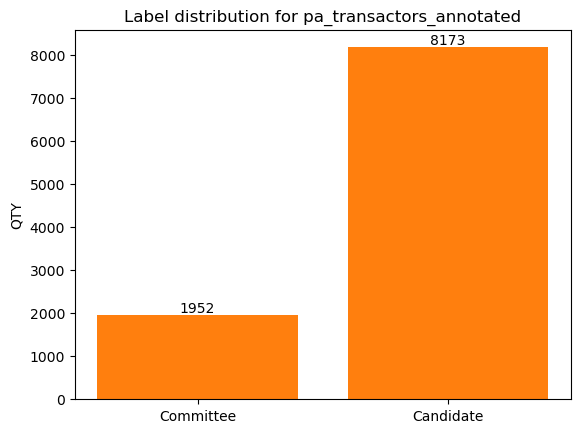

In [142]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

counts = pa_transcator_annotated.groupby(by='transactor_type', dropna=False).count()['id']
ax.bar(pa_transactor_annotaded_labels, counts)

bars = ax.bar(pa_transactor_annotaded_labels, counts)
ax.bar_label(bars)

ax.set_ylabel('QTY')
ax.set_title('Label distribution for pa_transactors_annotated')


plt.show()

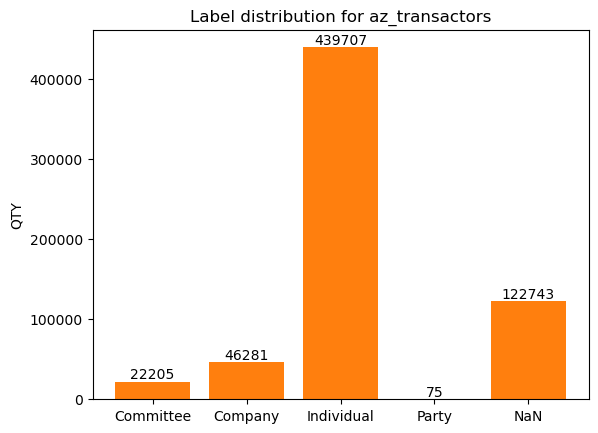

In [143]:

fig, ax = plt.subplots()

az_transactors_labels =['Committee', 'Company', 'Individual', 'Party', 'NaN']

counts = az_transcators.groupby(by='transactor_type', dropna=False).count()['id']
ax.bar(az_transactors_labels, counts)

bars = ax.bar(az_transactors_labels, counts)
ax.bar_label(bars)

ax.set_ylabel('QTY')
ax.set_title('Label distribution for az_transactors')


plt.show()

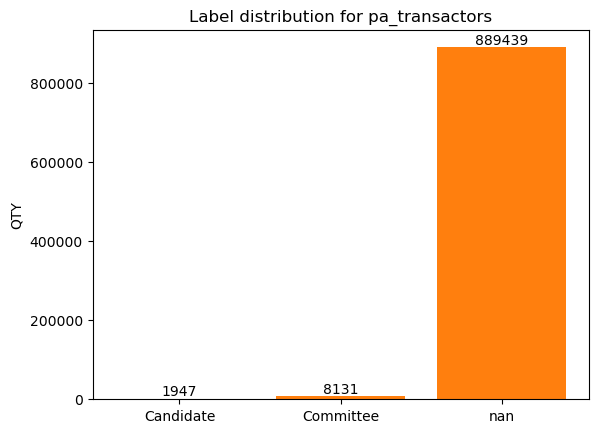

In [144]:

fig, ax = plt.subplots()

pa_transactors_labels = ['Candidate','Committee', 'nan']

counts = pa_transcators.groupby(by='transactor_type', dropna=False).count()['id']



ax.bar(pa_transactors_labels, counts)

bars = ax.bar(pa_transactors_labels, counts)
ax.bar_label(bars)


ax.set_ylabel('QTY')
ax.set_title('Label distribution for pa_transactors')


plt.show()